In [ ]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#Load Data
df = pd.read_csv("customer_churn_data.csv")

print(df.shape)
df.head()

#Clean data
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Drop nulls
df = df.dropna()

# Fix service columns
fix_cols = [
    'MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]

for col in fix_cols:
    df[col] = df[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

# Target
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# Drop ID
df = df.drop(columns=['customerID'])

print("Cleaned Data Shape:", df.shape)

#Feature engineering
df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'] + 1)

# Service count
service_cols = [
    'PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]

df['service_count'] = df[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)

# Tenure Bucket
df['tenure_bucket'] = pd.cut(
    df['tenure'],
    bins=[0,12,36,100],
    labels=['New','Medium','Loyal']
)

df['tenure_bucket'] = df['tenure_bucket'].astype(str)

# High value
df['high_value_customer'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

# Support risk
df['support_risk_score'] = (
    (df['OnlineSecurity'] == 'No').astype(int) +
    (df['TechSupport'] == 'No').astype(int)
)

print("Feature Engineering Done")

#Split data
X = df.drop(['Churn'], axis=1)
y = df['Churn']

# Reset index
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical:", cat_cols)
print("Numerical:", num_cols)

#Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#Pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])


(5880, 21)
Cleaned Data Shape: (5880, 20)
Feature Engineering Done
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_bucket']
Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'service_count', 'high_value_customer', 'support_risk_score']


In [25]:
#Models and cross validation
models = {
    "logistic": LogisticRegression(max_iter=1000),
    "random_forest": RandomForestClassifier(n_estimators=200)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_model = None
best_score = 0

for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f"{name} ROC-AUC:", scores.mean())
    
    if scores.mean() > best_score:
        best_score = scores.mean()
        best_model = pipe

logistic ROC-AUC: 0.48023678942885767
random_forest ROC-AUC: 0.5061172630587731


In [26]:
#Final Train
best_model.fit(X_train, y_train)

probs = best_model.predict_proba(X_test)[:,1]

print("Final ROC-AUC:", roc_auc_score(y_test, probs))

joblib.dump(best_model, "model.pkl")

Final ROC-AUC: 0.490512902105994


['model.pkl']

In [27]:
#Cost Optimization

def optimize_threshold(y_true, probs):
    thresholds = np.linspace(0,1,100)
    best_cost = float('inf')
    best_t = 0.5
    
    for t in thresholds:
        preds = (probs > t).astype(int)
        
        fn = np.sum((y_true == 1) & (preds == 0))
        fp = np.sum((y_true == 0) & (preds == 1))
        
        cost = fn * 10000 + fp * 1000
        
        if cost < best_cost:
            best_cost = cost
            best_t = t
            
    return best_t, best_cost

t, cost = optimize_threshold(y_test.values, probs)

print("Best Threshold:", t)
print("Minimum Cost:", cost)

Best Threshold: 0.23232323232323235
Minimum Cost: 594000


In [28]:
#Decision intelligence
def decision(prob):
    if prob < 0.3:
        return "Low", "No Action"
    elif prob < 0.7:
        return "Medium", "Email Offer"
    else:
        return "High", "Call + Discount"

print(decision(probs[0]))

('Medium', 'Email Offer')


In [29]:
#Deep Learning

import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score

# Preprocess data using same pipeline
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

X_train_tensor = torch.tensor(X_train_proc, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_proc, dtype=torch.float32)

# Model
class ChurnNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model_dl = ChurnNN(X_train_tensor.shape[1])

loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model_dl.parameters(), lr=0.001)

# Training
for epoch in range(20):
    optimizer.zero_grad()
    outputs = model_dl(X_train_tensor).squeeze()
    loss = loss_fn(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch} Loss: {loss.item()}")

# Evaluation
with torch.no_grad():
    preds = model_dl(X_test_tensor).numpy().flatten()

print("DL ROC-AUC:", roc_auc_score(y_test, preds))

Epoch 0 Loss: 0.6996269822120667
Epoch 1 Loss: 0.6969942450523376
Epoch 2 Loss: 0.6959837079048157
Epoch 3 Loss: 0.6949119567871094
Epoch 4 Loss: 0.694557785987854
Epoch 5 Loss: 0.6937547326087952
Epoch 6 Loss: 0.6932511925697327
Epoch 7 Loss: 0.6931176781654358
Epoch 8 Loss: 0.6930921673774719
Epoch 9 Loss: 0.6923912167549133
Epoch 10 Loss: 0.6929802298545837
Epoch 11 Loss: 0.6930301189422607
Epoch 12 Loss: 0.6930012106895447
Epoch 13 Loss: 0.693636417388916
Epoch 14 Loss: 0.6926885843276978
Epoch 15 Loss: 0.6932880282402039
Epoch 16 Loss: 0.6922699809074402
Epoch 17 Loss: 0.692747950553894
Epoch 18 Loss: 0.6921552419662476
Epoch 19 Loss: 0.6924152970314026
DL ROC-AUC: 0.4830681555195557


 98%|===================| 195/200 [00:34<00:00]        

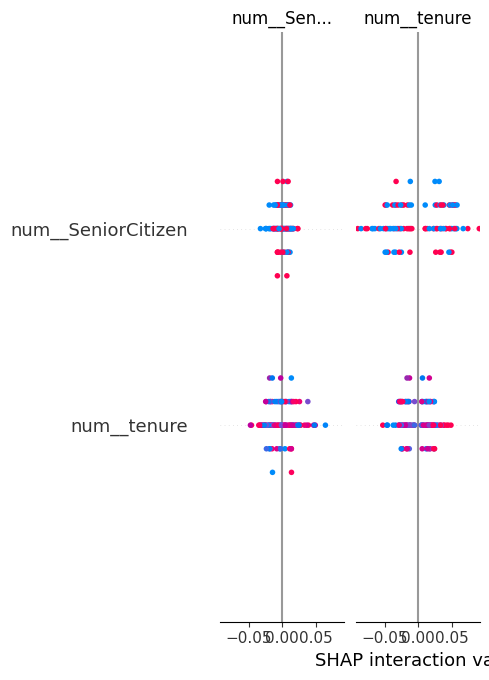

In [32]:
#SHAP Analysis

import shap

# Use trained pipeline
X_sample = X_train.sample(100)

explainer = shap.Explainer(best_model.named_steps['model'],
                           best_model.named_steps['prep'].transform(X_sample))

shap_values = explainer(best_model.named_steps['prep'].transform(X_sample))

shap.summary_plot(shap_values, feature_names=best_model.named_steps['prep'].get_feature_names_out())

c:\Users\IBuild\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 4 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


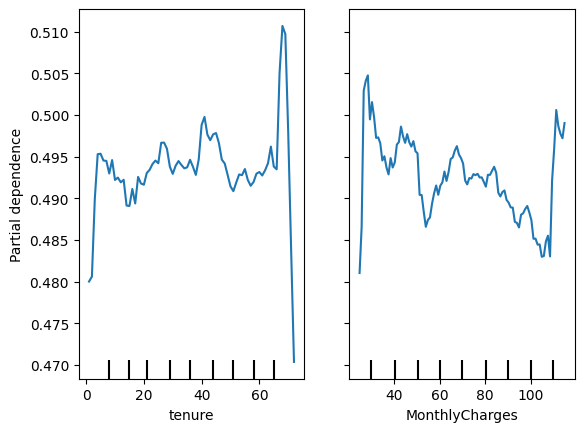

In [34]:
#Partial dependence plots(PDP)

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features = ['tenure', 'MonthlyCharges']

PartialDependenceDisplay.from_estimator(
    best_model,
    X_train,
    features
)

plt.show()

In [36]:
#Bias and Fairness analysis

print("Churn by Gender:\n")
print(df.groupby('gender')['Churn'].mean())

print("Churn by Gender:\n")
print(df.groupby('gender')['Churn'].mean())

#Model prediction bias
X_test_copy = X_test.copy()
X_test_copy['Actual'] = y_test
X_test_copy['Predicted'] = (probs > t).astype(int)

print("\nPrediction by Gender:\n")
print(X_test_copy.groupby('gender')['Predicted'].mean())

print("\nPrediction by SeniorCitizen:\n")
print(X_test_copy.groupby('SeniorCitizen')['Predicted'].mean())


Churn by Gender:

gender
Female    0.488737
Male      0.496949
Name: Churn, dtype: float64
Churn by Gender:

gender
Female    0.488737
Male      0.496949
Name: Churn, dtype: float64

Prediction by Gender:

gender
Female    1.0000
Male      0.9967
Name: Predicted, dtype: float64

Prediction by SeniorCitizen:

SeniorCitizen
0    0.996564
1    1.000000
Name: Predicted, dtype: float64


In [ ]:
#Decision intelligence

def decision_with_roi(prob):
    if prob < 0.3:
        return "Low", "No Action", 0
    elif prob < 0.7:
        return "Medium", "Email Offer", 500
    else:
        return "High", "Call + Discount", 2000

print(decision_with_roi(probs[0]))

('Medium', 'Email Offer', 500)
